# Part 1: Dataset, Problem & Feature/Target Identification 

# Task 1

In [2]:
import pandas as pd
df=pd.read_csv("house-prices-advanced-regression-techniques/train.csv")
print("shape of dataset : ",df.shape)
print("\nDatatypes od dataset :\n",df.dtypes)
print("\nFirst few rows of dataset :\n",df.head(10))
print("\nSummary statistics of dataset :\n",df.describe())

shape of dataset :  (1460, 81)

Datatypes od dataset :
 Id                 int64
MSSubClass         int64
MSZoning             str
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType             str
SaleCondition        str
SalePrice          int64
Length: 81, dtype: object

First few rows of dataset :
    Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   
5   6          50       RL         85.0    14115   Pave   NaN      IR1   
6   7          20       RL         75.0    10084   Pave   NaN      Reg   
7   8          60    

# Task 2

In [3]:
y = df["SalePrice"]
X = df.drop(columns=["SalePrice", "Id"])
numerical_features=X.select_dtypes(include=["int64","float64"]).columns
categorical_features=X.select_dtypes(include=["str"]).columns
print("Numerical features :\n",numerical_features)
print("\nCategorical features :\n",categorical_features)

Numerical features :
 Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold'],
      dtype='str')

Categorical features :
 Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinTy

# Task 2 interpretation
Dependent variable:
SalePrice:the price of the house that we want to predict.
Independent variables:
All other relevant columns in the dataset are independent variables.

# Task 3
This is a regression problem because the target variable SalePrice is a continuous numerical value that we want to predict. Therefore, the model will be evaluated using regression metrics such as MAE, MSE/RMSE, and R² rather than classification metrics such as accuracy or precision.

# Part 2: Data Preparation & Train/Test Split 

# Task 4

In [4]:
selected_features = [
    "GrLivArea",
    "OverallQual",
    "TotalBsmtSF",
    "GarageCars",
    "YearBuilt",
    "FullBath",
    "GarageArea",
    "1stFlrSF",
    "Neighborhood",
    "HouseStyle",
    "KitchenQual",
    "ExterQual"
]
X = df[selected_features].copy()
y = df["SalePrice"]
categorical_features = X.select_dtypes(include=["str"]).columns
X=pd.get_dummies(X,columns=categorical_features,drop_first=True)
print(X.shape)

(1460, 45)


# Task 4 interpretation
Categorical features were converted into numerical form using one-hot encoding because the categories do not have an inherent order. Numerical features were kept in their original form. SalePrice was used as the target variable, while Id was removed because it is only an identifier and does not provide meaningful information for predicting house prices.


# Task 5

In [5]:
X = X.fillna(X.median(numeric_only=True))
X = X.astype(int)
print("Data types:")
print(X.dtypes.value_counts())
print("\nTotal missing values:")
print(X.isnull().sum().sum())

Data types:
int64    45
Name: count, dtype: int64

Total missing values:
0


# Task 5 interpretation
After encoding the categorical features and handling missing values, all 45 input features are in numerical form. The dataset contains 0 missing values, so the feature matrix X is ready to be used for training the Linear Regression model.

# Task 6

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1168, 45)
X_test shape: (292, 45)
y_train shape: (1168,)
y_test shape: (292,)


# Task 6 interpretation
The dataset was divided into 80% training data and 20% testing data using train_test_split() with random_state=42. The training set contains 1,168 houses, while the test set contains 292 houses, with 45 features in each set.

# Part 3: Linear Regression & Predictions 

# Task 7

In [7]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


# Task 7 interpretation
A Linear Regression model was created using scikit-learn and trained on the 80% training dataset. The model learned the relationship between the selected house features and SalePrice by estimating coefficients for the input features.

# Task 8

In [8]:
y_pred = model.predict(X_test)
print("Predictions generated successfully.")
comparison = pd.DataFrame({
    "Actual Price": y_test.values[:10],
    "Predicted Price": y_pred[:10]
})

print(comparison)

Predictions generated successfully.
   Actual Price  Predicted Price
0        154500    138061.940777
1        325000    322748.328367
2        115000    113992.606228
3        159000    174611.240143
4        315500    305693.896700
5         75500     67683.608283
6        311500    233372.182669
7        146000    144665.705525
8         84500     67272.317728
9        135500    117450.665084


# Task 8 interpretation
The trained Linear Regression model was used to predict the SalePrice values of the test dataset. The predicted prices were compared with the actual prices for 10 test houses to observe how closely the model's predictions matched the real values.

# Part 4 :Coefficients & Intercept 

# Task 9

In [9]:
print("Intercept: ",model.intercept_)
print("Number of coefficients:", len(model.coef_))
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coefficients)

Intercept:  -372259.4891449179
Number of coefficients: 45
                 Feature   Coefficient
0              GrLivArea     70.085205
1            OverallQual  12456.439447
2            TotalBsmtSF     10.734439
3             GarageCars  10232.880946
4              YearBuilt    205.645277
5               FullBath   -502.019508
6             GarageArea      5.251397
7               1stFlrSF    -24.332059
8   Neighborhood_Blueste  -1631.001395
9    Neighborhood_BrDale  -2161.735146
10  Neighborhood_BrkSide  19518.683117
11  Neighborhood_ClearCr  51151.698167
12  Neighborhood_CollgCr  22798.184410
13  Neighborhood_Crawfor  43792.464212
14  Neighborhood_Edwards   1329.747602
15  Neighborhood_Gilbert  21768.830099
16   Neighborhood_IDOTRR   8998.785207
17  Neighborhood_MeadowV   1165.826001
18  Neighborhood_Mitchel  12459.630396
19    Neighborhood_NAmes  11891.062295
20  Neighborhood_NPkVill   8151.903644
21   Neighborhood_NWAmes  14653.108424
22  Neighborhood_NoRidge  75812.385291
23  Ne

# Task 9 interpretation
The Linear Regression model produced one intercept and 45 coefficients corresponding to the 45 encoded input features. A positive coefficient indicates that an increase in the feature is associated with an increase in the predicted house price, while a negative coefficient indicates the opposite, with other features held constant. For categorical variables, the coefficients represent the difference relative to the category that was omitted during one-hot encoding.

# Task 10
The intercept of -372,259.49 represents the model's predicted SalePrice when all input variables are zero.However, this situation is not realistic for an actual house, since the selected features cannot all meaningfully be zero. Therefore, the intercept does not have a direct real-world interpretation in this model. It mainly acts as the constant term required by the Linear Regression equation.

# Part 5:  Residuals & Regression Metrics

# Task 11

First 10 residuals:
892     16438.059223
1105     2251.671633
413      1007.393772
522    -15611.240143
1036     9806.103300
614      7816.391717
218     78127.817331
1160     1334.294475
649     17227.682272
887     18049.334916
Name: SalePrice, dtype: float64


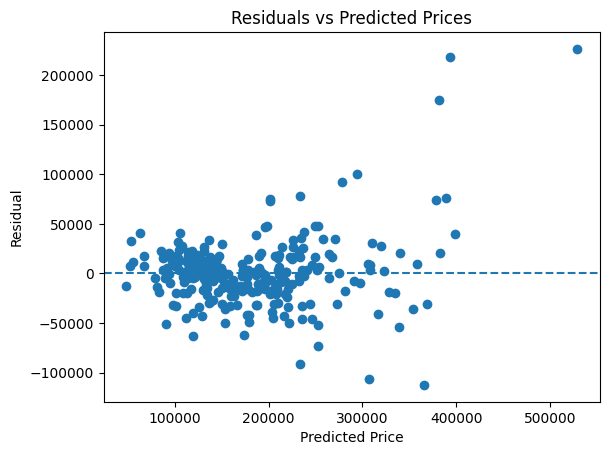

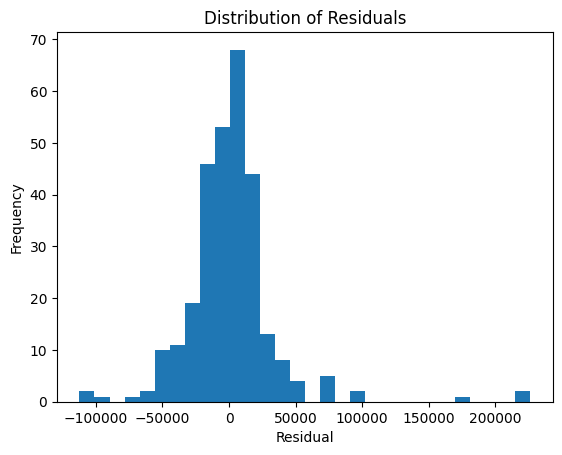

In [10]:
import matplotlib.pyplot as plt
residuals=y_test-y_pred
print("First 10 residuals:")
print(residuals[:10])
plt.scatter(y_pred,residuals)
plt.axhline(y=0,linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Prices")
plt.show()
plt.hist(residuals, bins=30)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")

plt.show()

# Task 11 interpretation
The residual analysis shows that most residuals are concentrated around zero, indicating that the model's predictions are reasonably close to the actual house prices for many observations. However, the residual-versus-predicted plot shows that the spread of errors increases for higher predicted prices, along with some large positive and negative residuals. The histogram also shows that most errors are centered around zero but the distribution is not perfectly symmetric and contains some large residuals. This suggests that the Linear Regression model does not have completely constant error variance and performs less consistently for some higher-priced houses.


# Task 12

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)
metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²"],
    "Value": [mae, mse, rmse, r2]
})

print(metrics)

MAE: 20964.644744410325
MSE: 1170114929.7909184
RMSE: 34206.94271329898
R²: 0.847449130821253
  Metric         Value
0    MAE  2.096464e+04
1    MSE  1.170115e+09
2   RMSE  3.420694e+04
3     R²  8.474491e-01


# Task 12 interpretation
The model achieved an MAE of  20,964.64, meaning its predictions are off by about $ 20,965 on average. The RMSE of 34,206.94 indicates that some larger errors are present. The R² score of 0.8474 shows that the model explains approximately 84.74% of the variation in house prices.

# Task 13
MAE measures the average absolute difference between actual and predicted prices and is easy to interpret because it uses the same unit as house price. MSE measures the average squared error and gives greater importance to large errors, but its squared units make it difficult to interpret directly. RMSE is the square root of MSE and represents prediction error in the original price unit while still emphasizing large errors. R² measures how much of the variation in house prices is explained by the model. For a non-technical stakeholder, MAE would be the easiest metric to communicate because it can be expressed directly as an average dollar error.

# Part 6: Training vs. Testing & Generalization

# Task 14

In [13]:
y_train_pred=model.predict(X_train)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)
performance = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²"],
    "Training": [train_mae, train_mse, train_rmse, train_r2],
    "Testing": [mae, mse, rmse, r2]
})

print(performance)

  Metric      Training       Testing
0    MAE  2.036887e+04  2.096464e+04
1    MSE  1.035126e+09  1.170115e+09
2   RMSE  3.217337e+04  3.420694e+04
3     R²  8.264537e-01  8.474491e-01


# Task 14 interpretation
The testing MAE, MSE, and RMSE are slightly higher than the corresponding training values, indicating somewhat larger prediction errors on unseen data. However, the differences are relatively small. The testing R² is slightly higher than the training R², showing that the test set has a slightly better fit for this particular split. Overall, the training and testing results are relatively close.

# Task 15

In [14]:
mae_gap = mae - train_mae
mse_gap = mse - train_mse
rmse_gap = rmse - train_rmse
r2_gap = r2 - train_r2

print("MAE Gap:", mae_gap)
print("MSE Gap:", mse_gap)
print("RMSE Gap:", rmse_gap)
print("R² Gap:", r2_gap)

MAE Gap: 595.7731711384367
MSE Gap: 134989057.7409444
RMSE Gap: 2033.57061695238
R² Gap: 0.020995468121165706


# Task 15 interpreatation
The  gap between training and testing results is reasonably small, so there is no strong evidence of overfitting. The model appears to generalize reasonably well to the unseen test data, although further validation could provide a more reliable conclusion.